# Run the 1D SC model solver for one equilibrium

In [10]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
import tempfile
import urllib.request # needed for geqdsk import
import netCDF4 as nc # OMFIT profile files are netCDF
ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve
from src.load_equil import initialize_inputs
from src.solver_sc import saarelma_connor_sc

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk

from examples.device_prediction.helper_functions import read_sparcpublic_profiles, psi_n_and_rho_psi, build_manual_profs, calc_pressure_profile, _print_profile_summary, read_popcon, _to_watts

In [17]:
import shutil

equil_num = 1
output_dir = f'test_firedrake_outer'
shutil.rmtree(output_dir, ignore_errors=True)  # wipe any stale out_dict.npy/failed.npy from a previous run
Path(output_dir).mkdir(parents=True, exist_ok=True)

In [18]:
# Equilibria parameters
geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode')
pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode')
kprof_loc = 'OMFITnc'
equil_num_total = len(list(pfile_dir.glob('*.cdf')))
if equil_num is None:
    equil_num = equil_num_total
print(f'Number of equilibria found: {equil_num_total}')
print(f'Number of equilibria to process: {equil_num}')
equilibria = initialize_inputs(equil_num, geqdsk_dir, pfile_dir, p_filetype='OMFITnc', select_equil='148789.03508') # Load in equilibria

Number of equilibria found: 302
Number of equilibria to process: 1
Equilibrium found without match
Equilibrium found without match
Equilibrium found without match
Selected 1 user-specified g/OMFITnc file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode/g148789.03508
  p: /mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode/IDA_148789_3.45_3.55_.cdf


In [19]:
# ── Heating power ────────────────────────────────────────────────────────────
# The DIII-D inputs carry NO heating power: the EFIT g-files have no slot for it
# and the OMFIT IDA netCDFs hold only kinetic/geometric profiles. Until per-shot
# P_NBI/P_ECH are pulled from MDSplus, use one representative value for the set.
#
# P_HEAT_TOT below is a ballpark for this HighPerfHMode database, obtained by
# integrating W_th = 3/2 * int (p_e + p_ion) dV from these very files and
# inverting IPB98(y,2) at H98 = 1: median ~7.3 MW (quartiles ~3.6-15 MW) over
# the 300 cases. Replace with measured PINJ + P_ECH per shot when available.
P_HEAT_TOT = 7.3e6      # W, total (NBI + ECH + Ohmic) heating, set-representative
ELECTRON_FRAC = 0.5     # Saarelma et al. take ~half the heating as the electron channel

# Fallback Zeff for the two files that carry no Zeff variable
# (IDA_125732_3.45_3.55_.cdf, IDA_128578_3.6_3.7_.cdf). 1.8 is the median of
# the profile-mean Zeff over the 300 files that do have it.
ZEFF_DEFAULT = 1.8
ZEFF_PSI_N = 0.95       # evaluate Zeff at the pedestal top, not on axis


def read_omfitnc_zeff(kprof_fp, psi_eval=ZEFF_PSI_N, default=ZEFF_DEFAULT):
    """Zeff at psi_N = psi_eval from an OMFIT IDA netCDF, averaged over its
    time slices. Returns `default` if the file has no usable Zeff."""
    with nc.Dataset(kprof_fp) as f:
        if 'Zeff' not in f.variables:
            print(f'  Zeff missing in {Path(kprof_fp).name}, using {default}')
            return float(default)
        z = np.ma.filled(f.variables['Zeff'][:], np.nan)   # (time, psi_n)
        psi = np.asarray(f.variables['psi_n'][:])
    z_t = np.nanmean(z, axis=0)
    good = np.isfinite(z_t)
    if not good.any():
        print(f'  Zeff all-NaN in {Path(kprof_fp).name}, using {default}')
        return float(default)
    return float(np.interp(psi_eval, psi[good], z_t[good]))


def read_omfitnc_profiles(kprof_fp):
    """Input kinetic profiles from an OMFIT IDA netCDF, time-averaged, in the
    layout calc_pressure_profile expects (psi_N_ne/psi_N_Te + SI ne + keV Te).

    This is the DIII-D analogue of the SPARC `manual_profs`: it is what the
    solver is fed, so the experimental pedestal pressure is computed from the
    same profiles the model saw. The IDA files carry no main-ion temperature or
    density (only the carbon channels, which are not the main ions), so Ti and
    ni are left out and calc_pressure_profile takes Ti = Te, ni = ne, i.e.
    p = 2*ne*Te.
    """
    with nc.Dataset(kprof_fp) as f:
        psi = np.asarray(f.variables['psi_n'][:], dtype=float)

        def _avg(name):
            if name not in f.variables:
                return None, ''
            var = f.variables[name]
            a = np.ma.filled(var[:], np.nan).astype(float)
            if a.ndim > 1:                      # average over the time axis
                a = np.nanmean(a, axis=0)
            return a, str(getattr(var, 'unit', '')).lower()

        ne, ne_unit = _avg('n_e')
        Te, Te_unit = _avg('T_e')

    if ne is None or Te is None:
        raise KeyError(f'{Path(kprof_fp).name} has no n_e/T_e')

    # IDA files store T in eV and n_e in m^-3; convert T to keV like the solver.
    def _to_keV(t, unit):
        if t is None:
            return None
        if unit in ('ev', 'electron volt', 'electron-volt'):
            return t / 1e3
        if unit in ('kev',):
            return t
        return t / 1e3 if np.nanmax(np.abs(t)) > 100 else t

    Te = _to_keV(Te, Te_unit)
    if ne_unit in ('10^19/m^3', '10^19 m^-3'):
        ne = ne * 1e19
    elif ne_unit in ('10^20/m^3', '10^20 m^-3'):
        ne = ne * 1e20

    # Drop points where any needed channel is NaN, keep the grid monotonic.
    good = np.isfinite(psi) & np.isfinite(ne) & np.isfinite(Te)
    if not good.any():
        raise ValueError(f'{Path(kprof_fp).name} has no finite ne/Te points')

    profiles = {
        'psi_N_ne': psi[good],
        'ne': ne[good],            # m^-3
        'psi_N_Te': psi[good],
        'Te': Te[good],            # keV
        'units': {'ne': 'm^-3', 'Te': 'keV'},
    }
    return profiles


In [20]:
# Scan parameters
x_res = 50
epednn_model = 'EPED1' # 'EPED1' or 'EPED_SPARC'
eped_tol_max = 1e-5
eped_iter_max = 5000
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0
verbose_EPEDNNloop = False
verbose_sc = True
species = 'D'
psi_N_inner = 0.85
first_step = "auto"
ne_grad_bc_loc = 'outer'

import itertools

# alpha_crits = np.array([0.01,10])
# nFC_x0s = np.append(np.logspace(14.7, 16, 3), 1e14)
# C_KBMs = np.array([0.3,1.0])
# De_chie_etgs = np.array([0.1,0.5])
# ncx_x0_ratios = np.array([0.01,0.5])
alpha_crits = np.array([0.01,2,10])
nFC_x0s = np.array([1e14,1e15,1e16,1e17])
C_KBMs = np.array([0.1,0.5,1.0])
De_chie_etgs = np.array([0.1,0.5,1.0])

scan_total = len(alpha_crits) * len(nFC_x0s) * len(C_KBMs) * len(De_chie_etgs)
print(f'Scanning {scan_total} parameter combinations')

Scanning 108 parameter combinations


In [21]:
for mhd_fp, kprof_fp in equilibria:
    equil_tag = Path(mhd_fp).name[1:]
    out_path = Path(output_dir) / equil_tag
    out_path.mkdir(parents=True, exist_ok=True)

    # Zeff is a profile in the OMFIT netCDF, so take it per equilibrium.
    Zeff = read_omfitnc_zeff(kprof_fp)  # dimensionless, at psi_N = ZEFF_PSI_N

    # Input profiles the solver is fed, kept so out_dict['profiles'] and the
    # experimental pedestal pressure both come from the same source.
    profiles = read_omfitnc_profiles(kprof_fp)
    psi_N_p, p_Pa, p_mode = calc_pressure_profile(profiles)

    # P_tot_e: heating power to electrons [W]. No per-shot power in the inputs,
    # so apply the set-representative estimate (see P_HEAT_TOT above).
    P_tot_e = P_HEAT_TOT * ELECTRON_FRAC

    print(f'{equil_tag}: Zeff = {Zeff:.3f}, P_tot_e = {P_tot_e/1e6:.2f} MW, pressure: {p_mode}')

    out_dir_ref = Path(out_path)

    base_model = saarelma_connor_sc(
        P_tot_e      = P_tot_e,
        species      = species,
        alpha_crit   = 1, # dummy value
        C_KBM        = 1, # dummy value
        De_chie_etg  = 1, # dummy value
        nFC_x0       = 1e15, # dummy value
        ncx_x0_ratio = 1, # not used
        psi_N_inner_boundary = psi_N_inner,
        mhd_fp       = mhd_fp,
        kprof_fp     = kprof_fp,
        kprof_loc    = kprof_loc,
        verbose      = verbose_sc,
    )

    i=0
    for combo in itertools.product(alpha_crits, C_KBMs, De_chie_etgs, nFC_x0s):
        free_params = {
            'alpha_crit': combo[0],
            'C_KBM': combo[1],
            'De_chie_etg': combo[2],
            'nFC_x0': combo[3],
        }

        out_dir = out_dir_ref / Path(f'fp{i}')
        out_dir.mkdir(parents=True, exist_ok=True)

        try:
            x_sol, ne_sol, dne_dx_sol = base_model.solve_sc(
                implementation="firedrake",
                x_res=x_res,
                free_params=free_params,
                eq6_form="complete",
                first_step=first_step,
                ne_grad_bc_loc=ne_grad_bc_loc,
                verbose=verbose_sc,
            )

            # Save model output
            out_dict = {
                'mhd_fp': mhd_fp,
                'kprof_fp': kprof_fp,
                'profiles': profiles,
                'free_params': free_params,
                'ne_sol': ne_sol, # profiles
                'x_sol': x_sol,
                'dne_dx_sol': dne_dx_sol,
                'p_mode': p_mode,
                'Zeff': Zeff,
                'P_tot_e': P_tot_e,
                'i': i,
            }
            np.save(out_dir / 'out_dict.npy', out_dict)
        except Exception as e:
            out_dict = {'failed': True, 'free_params': free_params, 'error': str(e)}
            np.save(out_dir / 'failed.npy', out_dict)

        if i%50 == 0:
            print(f'Scan {i+1} of {scan_total} completed')
        i+=1

148789.03508: Zeff = 1.671, P_tot_e = 3.65 MW, pressure: 2*ne*Te
[sc firedrake] x_inner         = -4.8488e-02 m
[sc firedrake] ne_grad_bc_loc  = 'outer'
[sc firedrake] dne/dx(x_inner) = -1.181e+20 m^-4  (p-file)
[sc firedrake] N'_in (source C)= -5.320e-01
[sc firedrake] dne/dx(0)       = -2.300e+21 m^-4  (p-file)
[sc firedrake] N'(0)           = -1.036e+01
[sc firedrake] hat_nFC(0)      = 9.291e-06
[sc firedrake] scales: L = 4.8488e-02 m, n0 = 1.0763e+19 m^-3, [D]_0 = 8.3864e+02 m^2/s


[sc firedrake eq7 grad-bc] it   1: N'(-1) = -5.320131e-01, N'(0) - target = 5.289e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -5.054124e-01, N'(0) - target = 5.553e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -6.118150e-01, N'(0) - target = 4.483e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -1.037426e+00, N'(0) - target = -4.425e-01
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -9.991860e-01, N'(0) - target = 6.350e-02
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -1.003985e+00, N'(0) - target = 9.362e-04
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -1.004057e+00, N'(0) - target = -1.982e-06
[sc firedrake eq7 grad-bc] it   8: N'(-1) = -1.004057e+00, N'(0) - target = 6.192e-11
[sc firedrake] picard it   1: |dne|_rel = 1.219e-01, alpha_bar = 1.5092, KBM ON
[sc firedrake eq7 grad-bc] it   1: N'(-1) = -1.004057e+00, N'(0) - target = 5.633e-01
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -9.538539e-01, N'(0) - target = 1.160e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -1.051469e+00,

[sc firedrake eq7 grad-bc] it   1: N'(-1) = -5.320131e-01, N'(0) - target = 3.852e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -5.054124e-01, N'(0) - target = 4.151e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -6.118150e-01, N'(0) - target = 2.935e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -8.687215e-01, N'(0) - target = -3.441e-01
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -8.417612e-01, N'(0) - target = 3.094e-02
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -8.439852e-01, N'(0) - target = 3.290e-04
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -8.440091e-01, N'(0) - target = -3.126e-07
[sc firedrake eq7 grad-bc] it   8: N'(-1) = -8.440091e-01, N'(0) - target = 3.038e-12
[sc firedrake] picard it   1: |dne|_rel = 1.864e-01, alpha_bar = 1.5092, KBM ON
[sc firedrake eq7 grad-bc] it   1: N'(-1) = -8.440091e-01, N'(0) - target = 7.781e-01
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -8.018087e-01, N'(0) - target = 1.288e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -9.084527e-01,

[sc firedrake eq7 grad-bc] it   4: N'(-1) = -4.080828e-01, N'(0) - target = -7.086e-03
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -4.078367e-01, N'(0) - target = 9.114e-06
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -4.078371e-01, N'(0) - target = 9.136e-10
[sc firedrake] picard it   1: |dne|_rel = 4.613e-01, alpha_bar = 1.5092, KBM ON
[sc firedrake eq7 grad-bc] it   1: N'(-1) = -4.078371e-01, N'(0) - target = 2.378e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -3.874452e-01, N'(0) - target = 2.782e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -4.690126e-01, N'(0) - target = 1.134e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -5.251328e-01, N'(0) - target = -5.772e-02
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -5.224144e-01, N'(0) - target = 1.216e-03
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -5.224705e-01, N'(0) - target = 1.304e-06
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -5.224705e-01, N'(0) - target = -2.949e-11
[sc firedrake] picard it   2: |dne|_rel = 1.573e-01, alph

[sc firedrake] x_inner         = -4.8488e-02 m
[sc firedrake] ne_grad_bc_loc  = 'outer'
[sc firedrake] dne/dx(x_inner) = -1.181e+20 m^-4  (p-file)
[sc firedrake] N'_in (source C)= -5.320e-01
[sc firedrake] dne/dx(0)       = -2.300e+21 m^-4  (p-file)
[sc firedrake] N'(0)           = -1.036e+01
[sc firedrake] hat_nFC(0)      = 9.291e-06
[sc firedrake] scales: L = 4.8488e-02 m, n0 = 1.0763e+19 m^-3, [D]_0 = 8.3864e+02 m^2/s
[sc firedrake eq7 grad-bc] it   1: N'(-1) = -5.320131e-01, N'(0) - target = 7.884e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -5.054124e-01, N'(0) - target = 7.987e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -6.118150e-01, N'(0) - target = 7.583e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -1.037426e+00, N'(0) - target = 6.029e+00
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -1.862851e+00, N'(0) - target = 2.553e+00
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -2.469067e+00, N'(0) - target = -2.477e+00
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -2.170500e+00,

[sc firedrake eq7 grad-bc] it   1: N'(-1) = -5.320131e-01, N'(0) - target = 7.884e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -5.054124e-01, N'(0) - target = 7.987e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -6.118150e-01, N'(0) - target = 7.583e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -1.037426e+00, N'(0) - target = 6.029e+00
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -1.862851e+00, N'(0) - target = 2.553e+00
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -2.469067e+00, N'(0) - target = -2.477e+00
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -2.170500e+00, N'(0) - target = 6.738e-01
[sc firedrake eq7 grad-bc] it   8: N'(-1) = -2.234336e+00, N'(0) - target = 1.806e-01
[sc firedrake eq7 grad-bc] it   9: N'(-1) = -2.257709e+00, N'(0) - target = -1.437e-02
[sc firedrake eq7 grad-bc] it  10: N'(-1) = -2.255985e+00, N'(0) - target = 3.013e-04
[sc firedrake eq7 grad-bc] it  11: N'(-1) = -2.256021e+00, N'(0) - target = 5.006e-07
[sc firedrake eq7 grad-bc] it  12: N'(-1) = -2.25602

[sc firedrake eq7 grad-bc] it   1: N'(-1) = -5.320131e-01, N'(0) - target = 6.561e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -5.054124e-01, N'(0) - target = 6.680e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -6.118150e-01, N'(0) - target = 6.210e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -1.037426e+00, N'(0) - target = 4.331e+00
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -2.018438e+00, N'(0) - target = -2.610e+00
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -1.649527e+00, N'(0) - target = 9.939e-01
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -1.751254e+00, N'(0) - target = 2.433e-01
[sc firedrake eq7 grad-bc] it   8: N'(-1) = -1.784220e+00, N'(0) - target = -2.358e-02
[sc firedrake eq7 grad-bc] it   9: N'(-1) = -1.781307e+00, N'(0) - target = 5.452e-04
[sc firedrake eq7 grad-bc] it  10: N'(-1) = -1.781373e+00, N'(0) - target = 1.214e-06
[sc firedrake eq7 grad-bc] it  11: N'(-1) = -1.781373e+00, N'(0) - target = -6.295e-11
[sc firedrake] picard it   1: |dne|_rel = 4.164e-01

[sc firedrake eq7 grad-bc] it   1: N'(-1) = -5.320131e-01, N'(0) - target = 7.496e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -5.054124e-01, N'(0) - target = 7.556e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -6.118150e-01, N'(0) - target = 7.324e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -1.037426e+00, N'(0) - target = 6.543e+00
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -2.739867e+00, N'(0) - target = 3.954e+00
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -3.389796e+00, N'(0) - target = 2.505e+00
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -3.530283e+00, N'(0) - target = 1.943e+00
[sc firedrake eq7 grad-bc] it   8: N'(-1) = -3.590988e+00, N'(0) - target = 1.560e+00
[sc firedrake eq7 grad-bc] it   9: N'(-1) = -3.621340e+00, N'(0) - target = 1.233e+00
[sc firedrake eq7 grad-bc] it  10: N'(-1) = -3.628499e+00, N'(0) - target = 1.103e+00
[sc firedrake eq7 grad-bc] it  11: N'(-1) = -3.632079e+00, N'(0) - target = 9.946e-01
[sc firedrake eq7 grad-bc] it  12: N'(-1) = -3.633869e

[sc firedrake] x_inner         = -4.8488e-02 m
[sc firedrake] ne_grad_bc_loc  = 'outer'
[sc firedrake] dne/dx(x_inner) = -1.181e+20 m^-4  (p-file)
[sc firedrake] N'_in (source C)= -5.320e-01
[sc firedrake] dne/dx(0)       = -2.300e+21 m^-4  (p-file)
[sc firedrake] N'(0)           = -1.036e+01
[sc firedrake] hat_nFC(0)      = 9.291e-06
[sc firedrake] scales: L = 4.8488e-02 m, n0 = 1.0763e+19 m^-3, [D]_0 = 8.3864e+02 m^2/s
[sc firedrake eq7 grad-bc] it   1: N'(-1) = -5.320131e-01, N'(0) - target = 7.884e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -5.054124e-01, N'(0) - target = 7.987e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -6.118150e-01, N'(0) - target = 7.583e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -1.037426e+00, N'(0) - target = 6.029e+00
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -1.862851e+00, N'(0) - target = 2.553e+00
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -2.469067e+00, N'(0) - target = -2.477e+00
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -2.170500e+00,

[sc firedrake eq7 grad-bc] it   1: N'(-1) = -5.320131e-01, N'(0) - target = 8.745e+00
[sc firedrake eq7 grad-bc] it   2: N'(-1) = -5.054124e-01, N'(0) - target = 8.798e+00
[sc firedrake eq7 grad-bc] it   3: N'(-1) = -6.118150e-01, N'(0) - target = 8.596e+00
[sc firedrake eq7 grad-bc] it   4: N'(-1) = -1.037426e+00, N'(0) - target = 7.934e+00
[sc firedrake eq7 grad-bc] it   5: N'(-1) = -2.739867e+00, N'(0) - target = 6.026e+00
[sc firedrake eq7 grad-bc] it   6: N'(-1) = -4.083729e+00, N'(0) - target = 4.342e+00
[sc firedrake eq7 grad-bc] it   7: N'(-1) = -4.516825e+00, N'(0) - target = 3.316e+00
[sc firedrake eq7 grad-bc] it   8: N'(-1) = -4.604300e+00, N'(0) - target = 2.865e+00
[sc firedrake eq7 grad-bc] it   9: N'(-1) = -4.626169e+00, N'(0) - target = 2.642e+00
[sc firedrake eq7 grad-bc] it  10: N'(-1) = -4.631636e+00, N'(0) - target = 2.544e+00
[sc firedrake eq7 grad-bc] it  11: N'(-1) = -4.634370e+00, N'(0) - target = 2.465e+00
[sc firedrake eq7 grad-bc] it  12: N'(-1) = -4.635053e

# Plotting

29 converged, 79 failed


Text(0.5, 1.0, '148789.03508: 29 converged scan points')

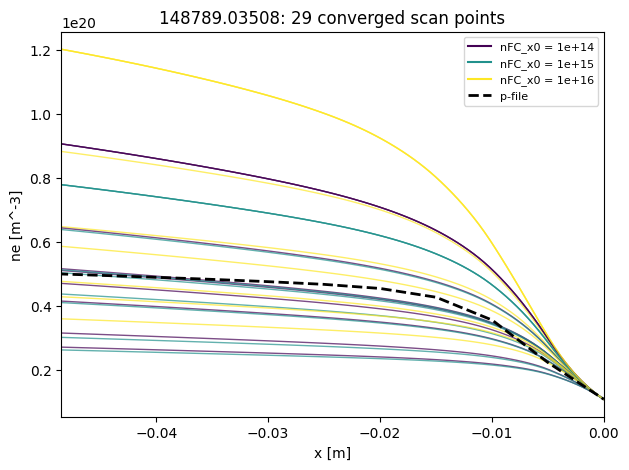

In [22]:
from matplotlib.lines import Line2D

# ── Plot every profile in the free-parameter scan ────────────────────────────
scan_dir = Path(output_dir) / equil_tag
color_by = 'nFC_x0'          # free parameter that sets the line colour

# Load every scan point that converged, in numerical fp order.
runs, n_failed = [], 0
for d in sorted(scan_dir.glob('fp*'), key=lambda p: int(p.name[2:])):
    if (d / 'out_dict.npy').exists():
        runs.append(np.load(d / 'out_dict.npy', allow_pickle=True).item())
    elif (d / 'failed.npy').exists():
        n_failed += 1
print(f'{len(runs)} converged, {n_failed} failed')

# One colour per distinct value of color_by, so the legend stays readable
# even though every individual curve is drawn.
levels = sorted({r['free_params'][color_by] for r in runs})
cmap = plt.get_cmap('viridis', len(levels))
colors = {v: cmap(i) for i, v in enumerate(levels)}

fig, ax = plt.subplots(figsize=(7, 5))
for r in runs:
    ax.plot(r['x_sol'], r['ne_sol'],
            color=colors[r['free_params'][color_by]], lw=1, alpha=0.7)

# p-file density, on the same real-space grid as x_sol (0 at the separatrix).
handles = [Line2D([], [], color=colors[v], label=f'{color_by} = {v:g}')
           for v in levels]
if 'base_model' in globals():
    ax.plot(base_model.x_init, base_model.n_e_pres, 'k--', lw=2)
    handles.append(Line2D([], [], color='k', ls='--', lw=2, label='p-file'))

ax.legend(handles=handles, fontsize=8)
ax.set_xlim(min(r['x_sol'].min() for r in runs), 0)
ax.set_xlabel('x [m]')
ax.set_ylabel('ne [m^-3]')
ax.set_title(f'{equil_tag}: {len(runs)} converged scan points')
